<div style="text-align: center">
    <h2><font size=6>MODELO 1 - RESNET-50</font></h2>
</d>
</div>

**Generadores con preprocessing de ResNet**

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "dataset_final/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    "dataset_final/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    "dataset_final/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())

Found 4455 images belonging to 6 classes.
Found 952 images belonging to 6 classes.
Found 959 images belonging to 6 classes.


**Cargar el modelo preentrenado (ResNet50)**

In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

**Compilar el modelo**

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Entrenamiento del modelo**

In [6]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=valid_generator
)

Epoch 1/30


C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


140/140 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.5575 - loss: 1.2821 - val_accuracy: 0.7605 - val_loss: 0.6622
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.7548 - loss: 0.6935 - val_accuracy: 0.8004 - val_loss: 0.5738
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.7731 - loss: 0.6391 - val_accuracy: 0.7616 - val_loss: 0.6197
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.7948 - loss: 0.5790 - val_accuracy: 0.8193 - val_loss: 0.5299
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.8174 - loss: 0.5304 - val_accuracy: 0.8183 - val_loss: 0.5176
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.8183 - loss: 0.5219 - val_accuracy: 0.8372 - val_loss: 0.4757
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8251 - loss: 0.4689 - val_accuracy: 0.8340 - val_loss: 0.5021
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8271 - loss: 0.4693 - val_accuracy: 0.833

In [8]:
val_loss, val_accuracy = model.evaluate(valid_generator, verbose=1)
print(f"Loss en validación: {val_loss}")
print(f"Precisión en validación: {val_accuracy}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8639 - loss: 0.4099
Loss en validación: 0.4186190664768219
Precisión en validación: 0.8581932783126831


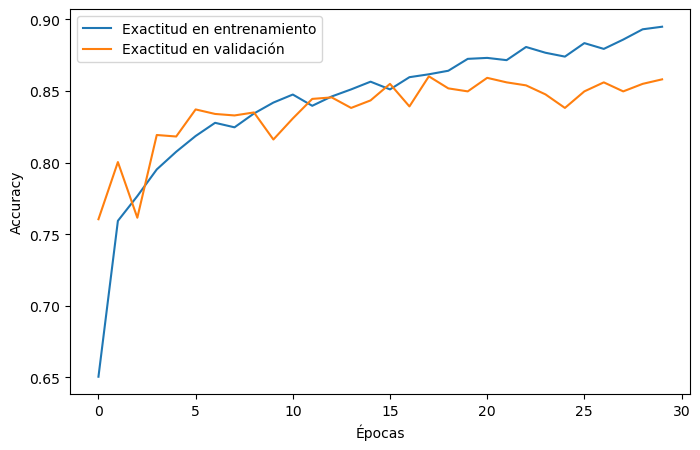

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Exactitud en entrenamiento')
plt.plot(history.history['val_accuracy'], label='Exactitud en validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

model = load_model("modelo_resnet50_fondos_ojos.h5")

Reiniciar el generador antes de predecir

In [6]:
test_generator.reset()

Realizar predicciones

In [7]:
predictions = model.predict(test_generator, verbose=1)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step


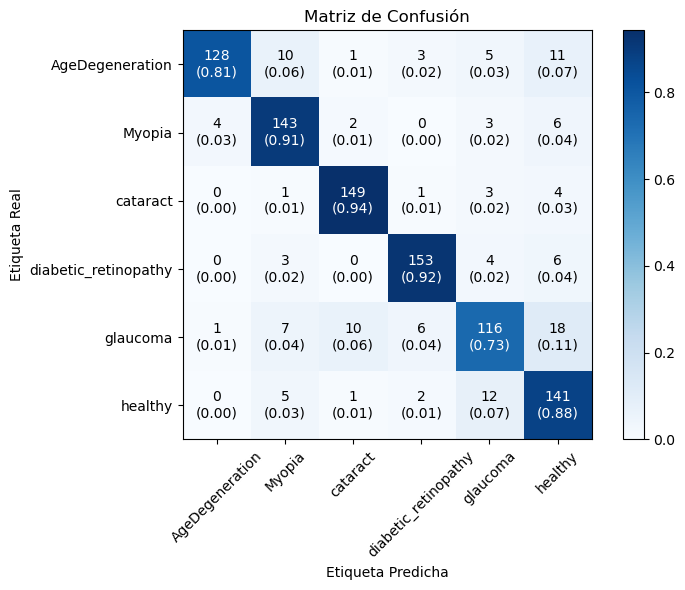

In [8]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()

classes = class_labels
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = conf_matrix_normalized.max() / 2.

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):

        absolute_value = conf_matrix[i, j]
        percentage_value = conf_matrix_normalized[i, j]

        plt.text(j, i,
                 f'{absolute_value}\n({percentage_value:.2f})',
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if percentage_value > thresh else "black")

plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

In [9]:
val_loss, val_accuracy = model.evaluate(valid_generator, verbose=1)

print(f"Loss en validación: {val_loss}")
print(f"Precisión en validación: {val_accuracy}")

C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8639 - loss: 0.4099
Loss en validación: 0.4186190664768219
Precisión en validación: 0.8581932783126831


In [10]:
print("Reporte de Clasificación:")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

Reporte de Clasificación:
                      precision    recall  f1-score   support

     AgeDegeneration       0.96      0.81      0.88       158
              Myopia       0.85      0.91      0.87       158
            cataract       0.91      0.94      0.93       158
diabetic_retinopathy       0.93      0.92      0.92       166
            glaucoma       0.81      0.73      0.77       158
             healthy       0.76      0.88      0.81       161

            accuracy                           0.87       959
           macro avg       0.87      0.86      0.87       959
        weighted avg       0.87      0.87      0.87       959



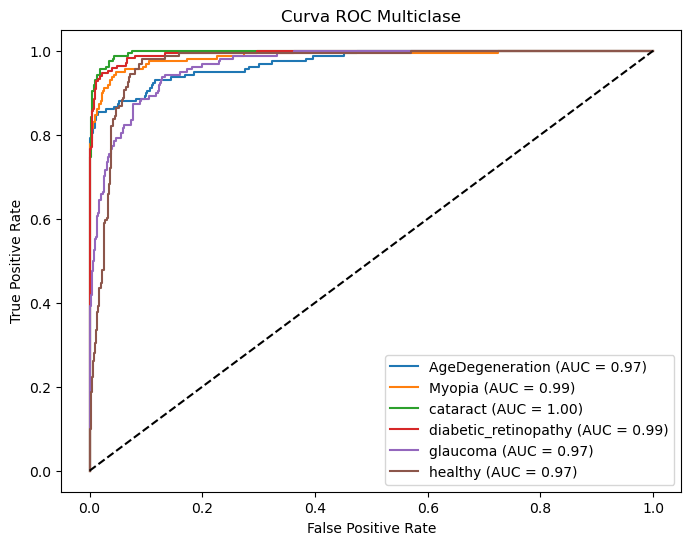

In [11]:
y_true_bin = label_binarize(true_classes, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))

for i in range(len(class_labels)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Multiclase')
plt.legend()

plt.show()